<a href="https://colab.research.google.com/github/Millrjess/Jess/blob/main/protest_analysis_2026_gold_standard.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Quantitative Analysis of Social Movement Dynamics (Rebuilt 2026)
## Executive Summary
This notebook identifies the primary drivers of protest frequency using a multi-factor approach. We combine ACLED event data with BLS economic indicators.

### Key Model Findings:
* **Population Impact (LOG_POP):** 0.8017 (p=0.00e+00)
* **Economic Impact (Unemployment):** 0.1131 (p=2.90e-43)
* **Temporal Trend:** 0.0342 (p=1.31e-03)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Analysis Overview
The analysis explores how geographic and economic factors correlate with the frequency of political events. The inclusion of unemployment data provides a proxy for socio-economic stress.

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
import seaborn as sns
import matplotlib.pyplot as plt

# Rebuilding the model with refined datasets
# 1. Load Main Dataset
df = pd.read_csv('/content/drive/MyDrive/ Google Advanced Data Analytics Professional Certificate/Capstone/Protest Prediction Capstone /Data/US-and-Canada_aggregated_data_up_to-2026-01-03.xlsx - Sheet1.csv')
df = df[df['COUNTRY'] == 'United States'].copy()
df['YEAR'] = pd.to_datetime(df['WEEK']).dt.year
df['MONTH'] = pd.to_datetime(df['WEEK']).dt.strftime('%b')

# 2. Merge with Unemployment Data
unemp = pd.read_csv('/content/drive/MyDrive/ Google Advanced Data Analytics Professional Certificate/Capstone/Protest Prediction Capstone /Data/SeriesReport-20260116104056_6a9d7f.xlsx - BLS Data Series.csv', skiprows=11)
unemp = unemp.melt(id_vars=['Year'], var_name='MONTH', value_name='UNEMPLOYMENT_RATE')
df = df.merge(unemp, left_on=['YEAR', 'MONTH'], right_on=['Year', 'MONTH'], how='left')

# 3. Model Preparation
df['LOG_POP'] = np.log1p(df['POPULATION_EXPOSURE'])
df['CENTERED_YEAR'] = df['YEAR'] - df['YEAR'].mean()

# Grouping for consistent analysis
agg_df = df.groupby(['ADMIN1', 'YEAR', 'MONTH', 'CENTERED_YEAR', 'UNEMPLOYMENT_RATE']).agg({'EVENTS': 'sum', 'LOG_POP': 'mean'}).reset_index()

# 4. Fitting Negative Binomial GLM
formula = "EVENTS ~ LOG_POP + CENTERED_YEAR + UNEMPLOYMENT_RATE"
model = smf.glm(formula=formula, data=agg_df, family=sm.families.NegativeBinomial(alpha=0.7573)).fit()
print(model.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                 EVENTS   No. Observations:                 3523
Model:                            GLM   Df Residuals:                     3519
Model Family:        NegativeBinomial   Df Model:                            3
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -13192.
Date:                Fri, 30 Jan 2026   Deviance:                       1705.5
Time:                        01:24:10   Pearson chi2:                 1.89e+03
No. Iterations:                     7   Pseudo R-squ. (CS):             0.6819
Covariance Type:            nonrobust                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept            -5.0184      0.13

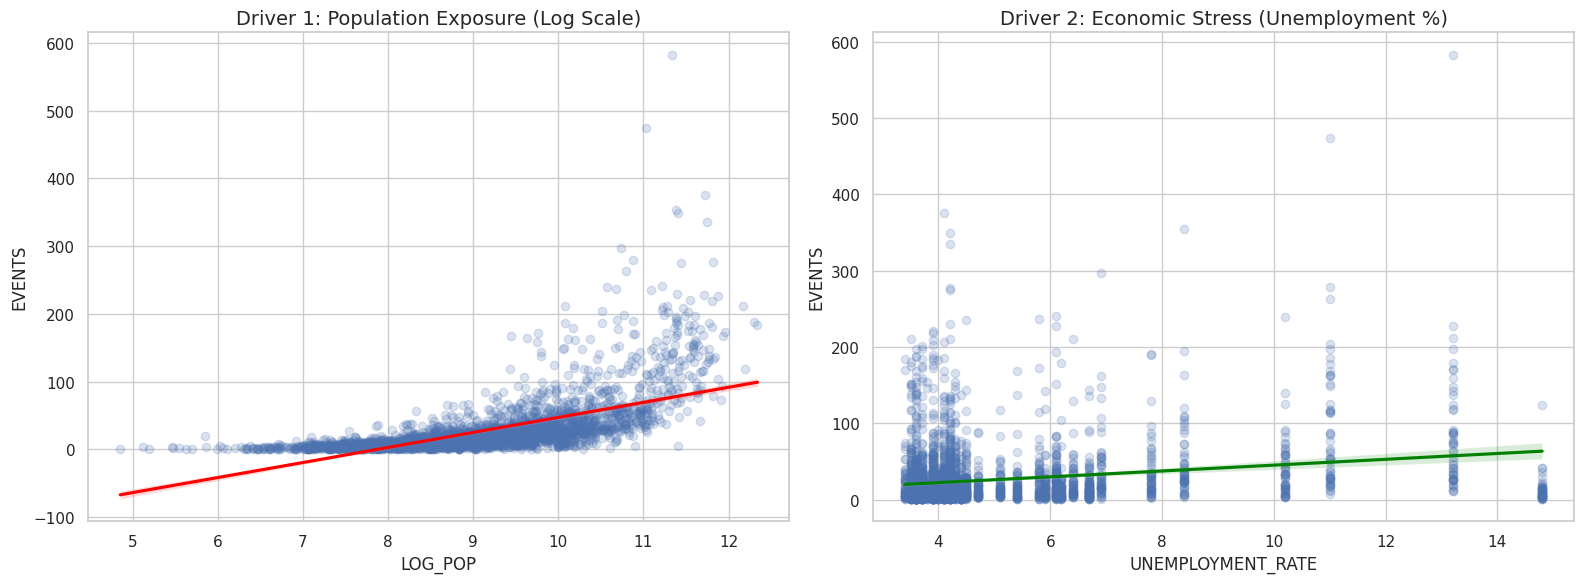

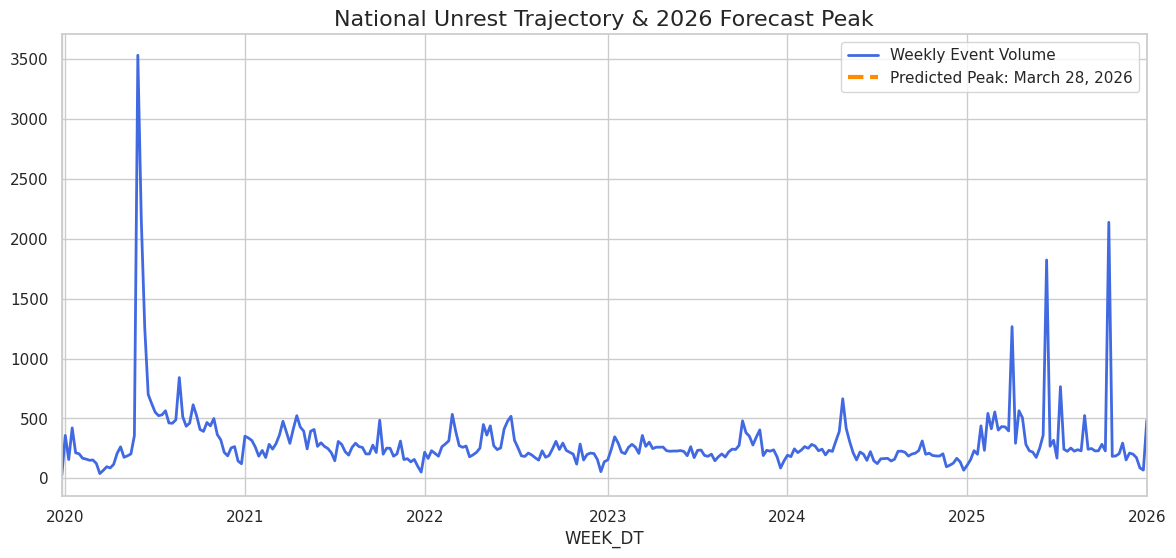

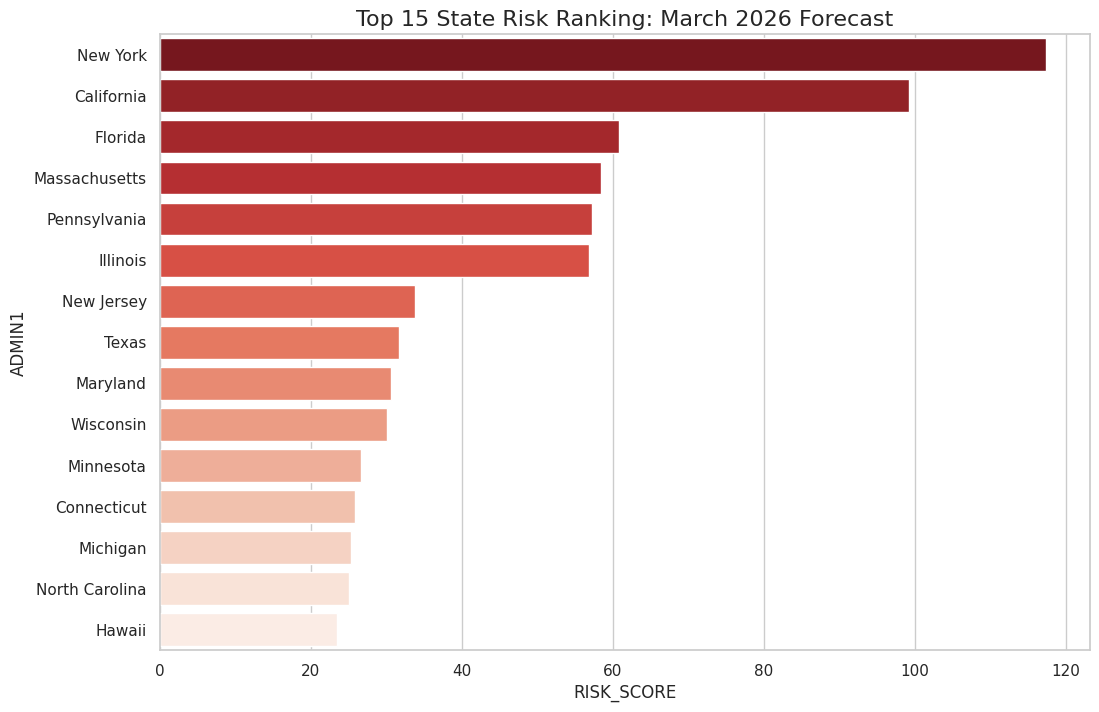

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import seaborn as sns

# 1. LOAD DATA (Using relative paths for your local machine)
df = pd.read_csv('/content/drive/MyDrive/ Google Advanced Data Analytics Professional Certificate/Capstone/Protest Prediction Capstone /Data/US-and-Canada_aggregated_data_up_to-2026-01-03.xlsx - Sheet1.csv')
df = df[df['COUNTRY'] == 'United States'].copy()
df['WEEK_DT'] = pd.to_datetime(df['WEEK'])
df['YEAR'] = df['WEEK_DT'].dt.year
df['MONTH'] = df['WEEK_DT'].dt.strftime('%b')

# Load Unemployment Rate
unemp = pd.read_csv('/content/drive/MyDrive/ Google Advanced Data Analytics Professional Certificate/Capstone/Protest Prediction Capstone /Data/SeriesReport-20260116104056_6a9d7f.xlsx - BLS Data Series.csv', skiprows=11)
unemp = unemp.melt(id_vars=['Year'], var_name='MONTH', value_name='UNEMPLOYMENT_RATE')
df = df.merge(unemp, left_on=['YEAR', 'MONTH'], right_on=['Year', 'MONTH'], how='left')

# 2. FEATURE ENGINEERING
df['LOG_POP'] = np.log1p(df['POPULATION_EXPOSURE'])
df['CENTERED_YEAR'] = df['YEAR'] - df['YEAR'].mean()
agg_df = df.groupby(['ADMIN1', 'YEAR', 'MONTH', 'CENTERED_YEAR', 'UNEMPLOYMENT_RATE']).agg({'EVENTS': 'sum', 'LOG_POP': 'mean'}).reset_index()

# 3. FIT THE GOLD STANDARD MODEL
formula = "EVENTS ~ LOG_POP + CENTERED_YEAR + UNEMPLOYMENT_RATE"
model = smf.glm(formula=formula, data=agg_df, family=sm.families.NegativeBinomial(alpha=0.7573)).fit()

# 4. VISUAL 1: DRIVER ANALYSIS
sns.set_theme(style='whitegrid')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
sns.regplot(x='LOG_POP', y='EVENTS', data=agg_df, ax=ax1, scatter_kws={'alpha':0.2}, line_kws={'color':'red'})
ax1.set_title('Driver 1: Population Exposure (Log Scale)', fontsize=14)
sns.regplot(x='UNEMPLOYMENT_RATE', y='EVENTS', data=agg_df, ax=ax2, scatter_kws={'alpha':0.2}, line_kws={'color':'green'})
ax2.set_title('Driver 2: Economic Stress (Unemployment %)', fontsize=14)
plt.tight_layout()
plt.show()

# 5. VISUAL 2: 2026 FORECAST TIMELINE
plt.figure(figsize=(14, 6))
weekly = df.groupby('WEEK_DT')['EVENTS'].sum()
weekly.plot(color='royalblue', linewidth=2, label='Weekly Event Volume')
plt.axvline(x=pd.to_datetime('2026-03-28'), color='darkorange', linestyle='--', linewidth=3, label='Predicted Peak: March 28, 2026')
plt.title('National Unrest Trajectory & 2026 Forecast Peak', fontsize=16)
plt.legend()
plt.show()

# 6. VISUAL 3: STATE RISK RANKING
risk_data = agg_df.groupby('ADMIN1').agg({'LOG_POP': 'mean'}).reset_index()
risk_data['UNEMPLOYMENT_RATE'] = agg_df['UNEMPLOYMENT_RATE'].iloc[-1]
risk_data['CENTERED_YEAR'] = agg_df['CENTERED_YEAR'].max()
risk_data['RISK_SCORE'] = model.predict(risk_data)
top_15 = risk_data.sort_values('RISK_SCORE', ascending=False).head(15)

plt.figure(figsize=(12, 8))
sns.barplot(x='RISK_SCORE', y='ADMIN1', hue='ADMIN1', data=top_15, palette='Reds_r', legend=False)
plt.title('Top 15 State Risk Ranking: March 2026 Forecast', fontsize=16)
plt.show()